In [ ]:
import medmnist
from medmnist import BloodMNIST, PathMNIST

def download_datasets(size=224):
    datasets_to_download = [BloodMNIST, PathMNIST]
    splits = ["train", "val", "test"]

    for dataset_class in datasets_to_download:
        print(f"\nStarte Download für: {dataset_class.__name__} (Größe: {size})")
        
        for split in splits:
            print(f"  Lade {split}-Split herunter...")
            # download=True startet den Download, falls nicht vorhanden
            # size=224 wählt die hohe Auflösung aus
            dataset = dataset_class(split=split, download=False, size=size)
            
            # Kurze Überprüfung der Datenform
            print(f"    Fertig! Anzahl Bilder: {len(dataset)}, Shape: {dataset.imgs.shape[1:]}")

if __name__ == "__main__":
    download_datasets(size=224) 


Starte Download für: BloodMNIST (Größe: 224)
  Lade train-Split herunter...
    Fertig! Anzahl Bilder: 11959, Shape: (224, 224, 3)
  Lade val-Split herunter...
    Fertig! Anzahl Bilder: 1712, Shape: (224, 224, 3)
  Lade test-Split herunter...
    Fertig! Anzahl Bilder: 3421, Shape: (224, 224, 3)

Starte Download für: PathMNIST (Größe: 224)
  Lade train-Split herunter...


100%|██████████| 12.6G/12.6G [4:14:10<00:00, 828kB/s]   


    Fertig! Anzahl Bilder: 89996, Shape: (224, 224, 3)
  Lade val-Split herunter...
    Fertig! Anzahl Bilder: 10004, Shape: (224, 224, 3)
  Lade test-Split herunter...
    Fertig! Anzahl Bilder: 7180, Shape: (224, 224, 3)



--- BloodMNIST Statistik ---
Beschreibung: The BloodMNIST is based on a dataset of individual normal cells, captured from individuals without infection, hematologic or oncologic disease and free of any pharmacologic treatment at the moment of blood collection. It contains a total of 17,092 images and is organized into 8 classes. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images with resolution 3×360×363 pixels are center-cropped into 3×200×200, and then resized into 3×28×28.
Klassen: {'0': 'basophil', '1': 'eosinophil', '2': 'erythroblast', '3': 'immature granulocytes(myelocytes, metamyelocytes and promyelocytes)', '4': 'lymphocyte', '5': 'monocyte', '6': 'neutrophil', '7': 'platelet'}


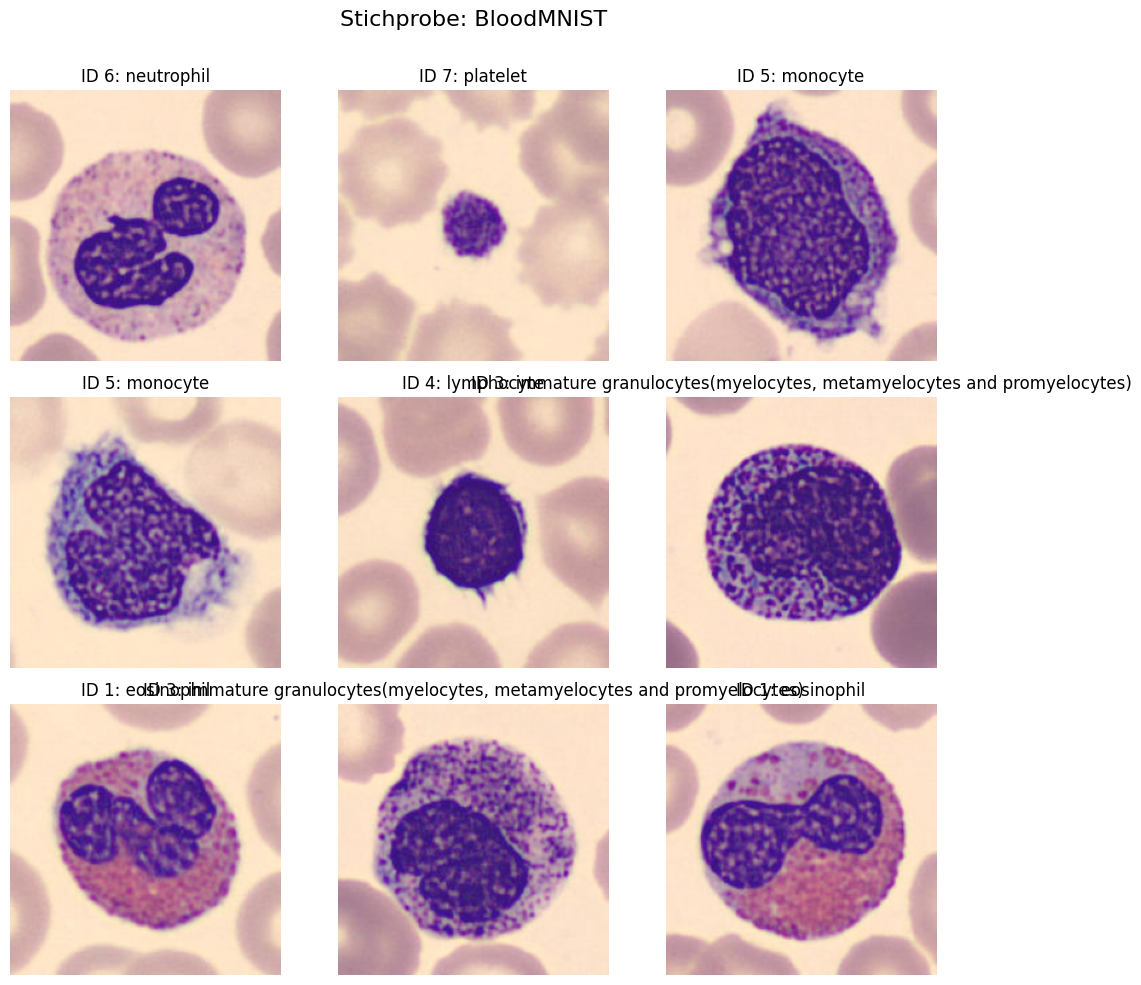

C:\Users\Micha\AppData\Local\Temp\ipykernel_10628\53876853.py:51: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


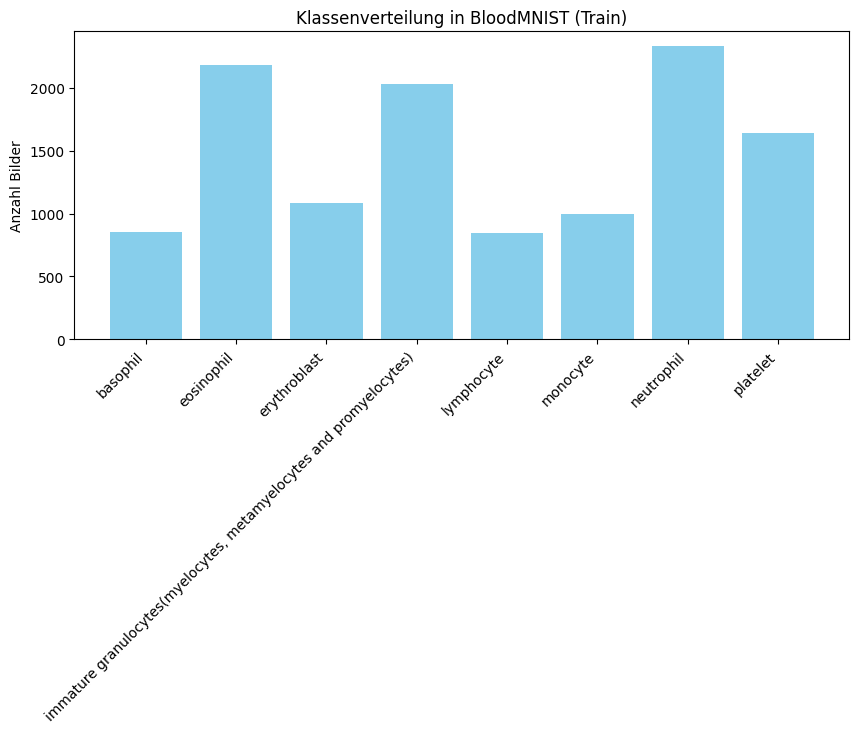


--- PathMNIST Statistik ---
Beschreibung: The PathMNIST is based on a prior study for predicting survival from colorectal cancer histology slides, providing a dataset (NCT-CRC-HE-100K) of 100,000 non-overlapping image patches from hematoxylin & eosin stained histological images, and a test dataset (CRC-VAL-HE-7K) of 7,180 image patches from a different clinical center. The dataset is comprised of 9 types of tissues, resulting in a multi-class classification task. We resize the source images of 3×224×224 into 3×28×28, and split NCT-CRC-HE-100K into training and validation set with a ratio of 9:1. The CRC-VAL-HE-7K is treated as the test set.
Klassen: {'0': 'adipose', '1': 'background', '2': 'debris', '3': 'lymphocytes', '4': 'mucus', '5': 'smooth muscle', '6': 'normal colon mucosa', '7': 'cancer-associated stroma', '8': 'colorectal adenocarcinoma epithelium'}


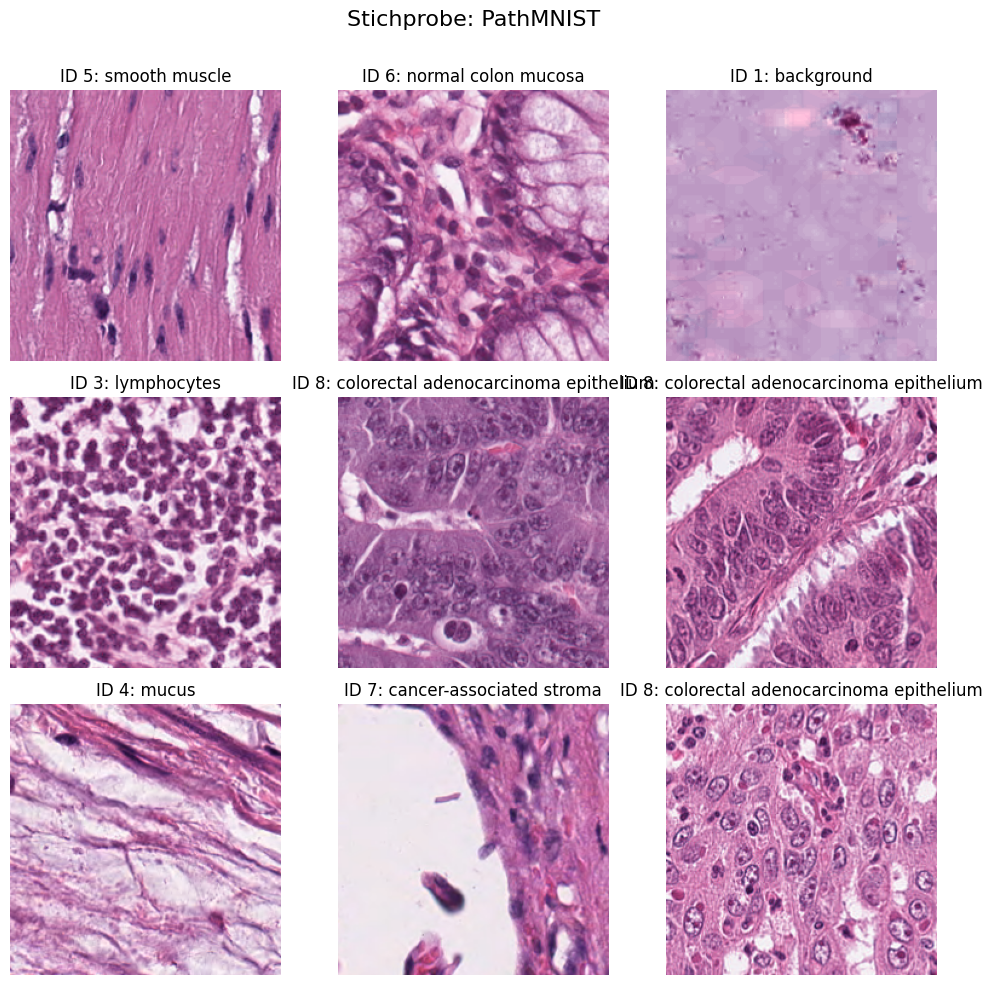

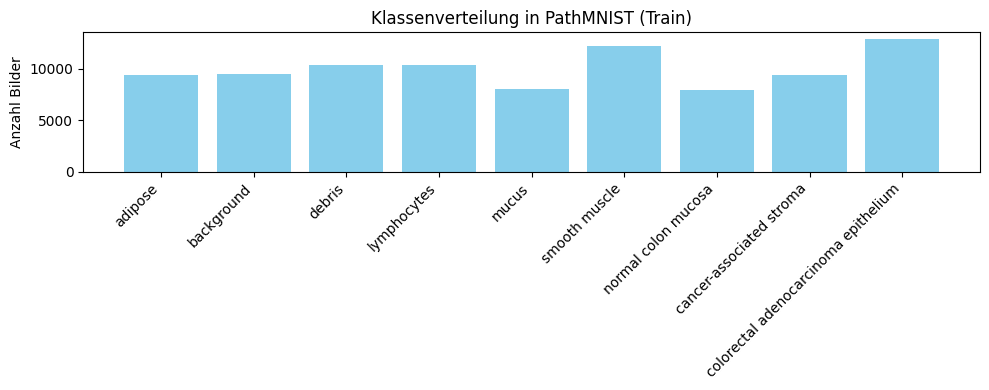

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from medmnist import BloodMNIST, PathMNIST

def visualize_medmnist():
    datasets = {
        "BloodMNIST": BloodMNIST(split='train', size=224, download=False),
        "PathMNIST": PathMNIST(split='train', size=224, download=False)
    }

    for name, ds in datasets.items():
        # 1. Informationen auslesen
        info = ds.info
        labels_dict = info['label'] # Mapping von ID zu Name
        print(f"\n--- {name} Statistik ---")
        print(f"Beschreibung: {info['description']}")
        print(f"Klassen: {labels_dict}")

        # 2. Bilder anzeigen (3x3 Grid)
        fig, axes = plt.subplots(3, 3, figsize=(10, 10))
        fig.suptitle(f"Stichprobe: {name}", fontsize=16)
        
        # Zufällige Indizes wählen
        indices = np.random.choice(len(ds), 9, replace=False)
        
        for i, idx in enumerate(indices):
            img, label = ds[idx]
            ax = axes[i // 3, i % 3]
            
            # Das Bild ist ein PIL Image, matplotlib kann das direkt anzeigen
            ax.imshow(img)
            
            # Label-Text heraussuchen
            label_name = labels_dict[str(label[0])]
            ax.set_title(f"ID {label[0]}: {label_name}")
            ax.axis('off')
        
        plt.tight_layout()
        plt.subplots_adjust(top=0.9)
        plt.show()

        # 3. Klassenverteilung visualisieren (Bar Chart)
        all_labels = ds.labels.flatten()
        unique, counts = np.unique(all_labels, return_counts=True)
        
        plt.figure(figsize=(10, 4))
        plt.bar([labels_dict[str(u)] for u in unique], counts, color='skyblue')
        plt.xticks(rotation=45, ha='right')
        plt.title(f"Klassenverteilung in {name} (Train)")
        plt.ylabel("Anzahl Bilder")
        plt.tight_layout()
        plt.show()


visualize_medmnist()

In [1]:
import torch


# device = torch.cuda.is_available()
# device

print(torch.__version__)

2.11.0+cu130


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, ConcatDataset
from torchvision import models, transforms
from medmnist import PathMNIST, BloodMNIST
import numpy as np

NUM_SAMPLES_PER_CLASS = 50  # Simulation von "wenig Daten"
BATCH_SIZE = 32

# 2. Datenvorbereitung & Transformationen
# ResNet erwartet normalerweise 224x224 (auch wenn MedMNIST 28x28 ist)
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Lade Ziel-Datensatz (PathMNIST)
train_dataset = PathMNIST(split='train', transform=data_transform, download=False, size=224)
val_dataset = PathMNIST(split='val', transform=data_transform, download=False, size=224)

def get_balanced_subset(dataset, n_per_class):
    """ Erstellt einen kleinen, balancierten Sub-Datensatz """
    labels = dataset.labels.flatten()
    indices = []
    for i in np.unique(labels):
        class_indices = np.where(labels == i)[0]
        selected_indices = np.random.choice(class_indices, n_per_class, replace=False)
        indices.extend(selected_indices)
    return Subset(dataset, indices)

# Erstelle kleine Trainingsmenge
small_train_ds = get_balanced_subset(train_dataset, NUM_SAMPLES_PER_CLASS)
train_loader = DataLoader(small_train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [2]:
# 1. Lade BloodMNIST
blood_train_ds = BloodMNIST(split='train', transform=data_transform, download=False, size=224)

In [3]:
#Lade PathMNIST Testdaten

test_dataset = PathMNIST(split='test', transform=data_transform, download=False, size=224)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [4]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
# --- Bestehender Code (vereinfacht) ---
# PathMNIST hat 9 Klassen (0 bis 8)
# Wir definieren das "Unbekannt"-Label als 9
UNKNOWN_LABEL = 9 
NUM_UNKNOWN_SAMPLES = 400 # Wie viele "fremde" Bilder wir hinzufügen


# 2. Wähle eine Stichprobe aus BloodMNIST
# Wir nehmen hier einfach die ersten X Bilder, da wir die internen Labels eh ignorieren
blood_indices = np.arange(NUM_UNKNOWN_SAMPLES)
small_blood_ds = Subset(blood_train_ds, blood_indices)

# 3. Ein Wrapper, um die Labels auf "9" (Unknown) zu setzen
class LabelWrapper(torch.utils.data.Dataset):
    def __init__(self, dataset, new_label):
        self.dataset = dataset
        self.new_label = new_label
        
    def __getitem__(self, index):
        image, _ = self.dataset[index]
        
        # FIX: Das Label muss die gleiche Form haben wie bei PathMNIST.
        # MedMNIST nutzt üblicherweise ein numpy-Array mit einem Element.
        return image, np.array([self.new_label], dtype=np.int64)
        
    def __len__(self):
        return len(self.dataset)

# Erstelle den "Unbekannt"-Datensatz
unknown_ds = LabelWrapper(small_blood_ds, UNKNOWN_LABEL)

# 4. Kombiniere PathMNIST (small_train_ds) mit dem Unknown-Set
combined_train_ds = ConcatDataset([small_train_ds, unknown_ds])

# 5. Neuer DataLoader für das Training
train_loader_combined = DataLoader(combined_train_ds, batch_size=BATCH_SIZE, shuffle=True)

print(f"PathMNIST Samples: {len(small_train_ds)}")
print(f"Unknown (BloodMNIST) Samples: {len(unknown_ds)}")
print(f"Gesamtgröße: {len(combined_train_ds)}")

PathMNIST Samples: 450
Unknown (BloodMNIST) Samples: 400
Gesamtgröße: 850


In [ ]:
# 1. Konfiguration für Phase 1
NUM_CLASSES_WITH_UNKNOWN = 10  # 9 PathMNIST + 1 BloodMNIST
NUM_EPOCHS_PHASE1 = 50 # Phase 1 meist kürzer
LR = 0.0001

# 2. Modell für Phase 1 definieren
def get_model_phase1(num_classes):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    num_ftrs = model.fc.in_features
    # Hier setzen wir 10 Ausgänge
    model.fc = nn.Linear(num_ftrs, num_classes)
    return model.to(DEVICE)

model = get_model_phase1(num_classes=NUM_CLASSES_WITH_UNKNOWN)

# 3. Training Loop für den kombinierten Datensatz
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

# WICHTIG: Nutze hier den 'train_loader_combined' aus dem vorherigen Schritt!
print(f"Starte Phase 1 Training auf {DEVICE}...")
print(f"Training mit {len(combined_train_ds)} Bildern (inkl. Unbekannt-Klasse)")


# Speicherung der besten Gewichte
best_val_acc = 0.0
best_model_weights = None


for epoch in range(NUM_EPOCHS_PHASE1):
    model.train()
    running_loss = 0.0
    # Nutze den kombinierten Loader (Path + Blood)
    for inputs, targets in train_loader_combined: 
        inputs, targets = inputs.to(DEVICE), targets.flatten().to(DEVICE).long()
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    # Validierung (nur auf den originalen PathMNIST Val-Daten)
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in val_loader: # Val-Set hat nur 9 Klassen
            inputs, targets = inputs.to(DEVICE), targets.flatten().to(DEVICE).long()
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()
    val_acc = correct / total
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_weights = model.state_dict().copy()  # Speichere die besten Gewichte 
    print(f"Epoch {epoch+1}/{NUM_EPOCHS_PHASE1} - Loss: {running_loss/len(train_loader_combined):.4f} - Val Acc: {100 * val_acc:.2f}%")

print("Phase 1 abgeschlossen.")

Starte Phase 1 Training auf cuda...
Training mit 900 Bildern (inkl. Unbekannt-Klasse)
Epoch 1/50 - Loss: 0.7234 - Val Acc: 88.71%
Epoch 2/50 - Loss: 0.1626 - Val Acc: 91.85%
Epoch 3/50 - Loss: 0.0901 - Val Acc: 90.97%
Epoch 4/50 - Loss: 0.0379 - Val Acc: 92.43%
Epoch 5/50 - Loss: 0.0718 - Val Acc: 92.34%
Epoch 6/50 - Loss: 0.0367 - Val Acc: 90.76%
Epoch 7/50 - Loss: 0.0271 - Val Acc: 90.74%
Epoch 8/50 - Loss: 0.0277 - Val Acc: 90.94%
Epoch 9/50 - Loss: 0.0743 - Val Acc: 87.21%
Epoch 10/50 - Loss: 0.0555 - Val Acc: 91.69%
Epoch 11/50 - Loss: 0.0237 - Val Acc: 92.65%
Epoch 12/50 - Loss: 0.0287 - Val Acc: 90.57%
Epoch 13/50 - Loss: 0.0143 - Val Acc: 92.34%
Epoch 14/50 - Loss: 0.0124 - Val Acc: 92.88%
Epoch 15/50 - Loss: 0.0063 - Val Acc: 92.96%
Epoch 16/50 - Loss: 0.0062 - Val Acc: 92.80%
Epoch 17/50 - Loss: 0.0392 - Val Acc: 91.05%
Epoch 18/50 - Loss: 0.0443 - Val Acc: 88.50%
Epoch 19/50 - Loss: 0.0508 - Val Acc: 91.41%
Epoch 20/50 - Loss: 0.0144 - Val Acc: 92.85%
Epoch 21/50 - Loss: 0.0

In [ ]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score
import torch.nn as nn
import os 

print("\n--- Starte Phase 2: Fine-tuning auf 9 Klassen ---")

# 1. Modell-Umbau
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 9) # Zurück auf die 9 Original-Klassen
model = model.to(DEVICE)

# 2. Konfiguration für Phase 2
optimizer = optim.Adam(model.parameters(), lr=0.0001) 
criterion = nn.CrossEntropyLoss()
NUM_EPOCHS_PHASE2 = 30 

#  Vorbereitung für Model Checkpointing 
best_val_acc = 0.0
best_model_path = "best_model_phase2.pth"

# Speicher für die Ergebnisse
history = {"train_loss": [], "val_acc": [], "val_balanced_acc": []}

for epoch in range(NUM_EPOCHS_PHASE2):
    # --- TRAINING ---
    model.train()
    running_loss = 0.0
    for inputs, targets in train_loader: # Nur PathMNIST (50 Samples/Klasse)
        inputs, targets = inputs.to(DEVICE), targets.flatten().to(DEVICE).long()
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    # --- VALIDIERUNG ---
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(DEVICE), targets.flatten().to(DEVICE).long()
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
    
    # Metriken berechnen
    acc = accuracy_score(all_targets, all_preds)
    bal_acc = balanced_accuracy_score(all_targets, all_preds)
    avg_loss = running_loss / len(train_loader)
    
    # In History speichern
    history["train_loss"].append(avg_loss)
    history["val_acc"].append(acc)
    history["val_balanced_acc"].append(bal_acc)
    
    print(f"Epoch {epoch+1}/{NUM_EPOCHS_PHASE2}:")
    print(f"  Train Loss: {avg_loss:.4f}")
    print(f"  Val Acc: {acc*100:.2f}% | Val Balanced Acc: {bal_acc*100:.2f}%")

    # --- NEU: Bestes Modell speichern ---
    if acc > best_val_acc:
        best_val_acc = acc
        # Speichert die Gewichte des Modells als Datei
        torch.save(model.state_dict(), best_model_path)
        print(f"  --> Neues bestes Modell gespeichert! (Val Acc: {best_val_acc*100:.2f}%)")

print("\n--- Training Beendet ---")

# --- NEU: Das beste Modell am Ende wieder laden ---
# Nach 30 Epochen ist das Modell in der Regel overfittet.
# Wir laden nun den Stand aus der Epoche, die am besten war.
if os.path.exists(best_model_path):
    model.load_state_dict(torch.load(best_model_path))
    print(f"Bestes Modell aus Phase 2 erfolgreich geladen (Val Acc: {best_val_acc*100:.2f}%)")


--- Starte Phase 2: Fine-tuning auf 9 Klassen ---
Epoch 1/30:
  Train Loss: 0.9860
  Val Acc: 92.93% | Val Balanced Acc: 92.88%
  --> Neues bestes Modell gespeichert! (Val Acc: 92.93%)
Epoch 2/30:
  Train Loss: 0.1587
  Val Acc: 93.33% | Val Balanced Acc: 93.41%
  --> Neues bestes Modell gespeichert! (Val Acc: 93.33%)
Epoch 3/30:
  Train Loss: 0.0904
  Val Acc: 92.30% | Val Balanced Acc: 92.64%
Epoch 4/30:
  Train Loss: 0.0930
  Val Acc: 91.38% | Val Balanced Acc: 91.61%
Epoch 5/30:
  Train Loss: 0.1003
  Val Acc: 90.62% | Val Balanced Acc: 90.81%
Epoch 6/30:
  Train Loss: 0.0913
  Val Acc: 92.06% | Val Balanced Acc: 91.96%
Epoch 7/30:
  Train Loss: 0.0622
  Val Acc: 92.95% | Val Balanced Acc: 92.90%
Epoch 8/30:
  Train Loss: 0.0720
  Val Acc: 92.68% | Val Balanced Acc: 92.77%
Epoch 9/30:
  Train Loss: 0.0990
  Val Acc: 93.18% | Val Balanced Acc: 93.10%
Epoch 10/30:
  Train Loss: 0.1232
  Val Acc: 92.36% | Val Balanced Acc: 92.33%
Epoch 11/30:
  Train Loss: 0.0554
  Val Acc: 91.16% | 

In [7]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score
import os # Falls nicht schon weiter oben im Skript importiert

print("\n--- Starte BASELINE-Lauf (Standard Transfer Learning) ---")
print(f"Training direkt auf {len(small_train_ds)} PathMNIST Bildern...")

# 1. Baseline Modell initialisieren (Standard ImageNet Gewichte)
baseline_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
num_ftrs = baseline_model.fc.in_features
baseline_model.fc = nn.Linear(num_ftrs, 9) # Direkt die 9 Zielklassen
baseline_model = baseline_model.to(DEVICE)

# 2. Konfiguration
optimizer_base = optim.Adam(baseline_model.parameters(), lr=0.0001) 
criterion = nn.CrossEntropyLoss()
NUM_EPOCHS_BASELINE = 80 

# --- NEU: Vorbereitung für Model Checkpointing ---
best_val_acc_base = 0.0
best_model_path_base = "best_model_baseline.pth"

# Speicher für die Metriken
history_baseline = {"train_loss": [], "val_acc": [], "val_balanced_acc": []}

for epoch in range(NUM_EPOCHS_BASELINE):
    # --- TRAINING ---
    baseline_model.train()
    running_loss = 0.0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(DEVICE), targets.flatten().to(DEVICE).long()
        
        optimizer_base.zero_grad()
        outputs = baseline_model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer_base.step()
        
        running_loss += loss.item()
    
    avg_train_loss = running_loss / len(train_loader)
    
    # --- VALIDIERUNG ---
    baseline_model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(DEVICE), targets.flatten().to(DEVICE).long()
            outputs = baseline_model(inputs)
            _, predicted = torch.max(outputs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
    
    # Metriken berechnen
    acc = accuracy_score(all_targets, all_preds)
    bal_acc = balanced_accuracy_score(all_targets, all_preds)
    
    # In History speichern
    history_baseline["train_loss"].append(avg_train_loss)
    history_baseline["val_acc"].append(acc)
    history_baseline["val_balanced_acc"].append(bal_acc)
    
    # Ausgabe (exakt wie in deinem anderen Code)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS_BASELINE}:")
    print(f"  Train Loss: {avg_train_loss:.4f}")
    print(f"  Val Acc: {acc*100:.2f}% | Val Balanced Acc: {bal_acc*100:.2f}%")

    # --- NEU: Bestes Baseline-Modell speichern ---
    if acc > best_val_acc_base:
        best_val_acc_base = acc
        torch.save(baseline_model.state_dict(), best_model_path_base)
        print(f"  --> Neues bestes Baseline-Modell gespeichert! (Val Acc: {best_val_acc_base*100:.2f}%)")

print("\n--- Baseline Lauf Beendet ---")

# --- NEU: Das beste Baseline-Modell am Ende wieder laden ---
if os.path.exists(best_model_path_base):
    baseline_model.load_state_dict(torch.load(best_model_path_base))
    print(f"Bestes Baseline-Modell erfolgreich geladen (Val Acc: {best_val_acc_base*100:.2f}%)")


--- Starte BASELINE-Lauf (Standard Transfer Learning) ---
Training direkt auf 450 PathMNIST Bildern...
Epoch 1/80:
  Train Loss: 1.1584
  Val Acc: 85.50% | Val Balanced Acc: 85.65%
  --> Neues bestes Baseline-Modell gespeichert! (Val Acc: 85.50%)
Epoch 2/80:
  Train Loss: 0.2864
  Val Acc: 91.19% | Val Balanced Acc: 91.36%
  --> Neues bestes Baseline-Modell gespeichert! (Val Acc: 91.19%)
Epoch 3/80:
  Train Loss: 0.1626
  Val Acc: 92.63% | Val Balanced Acc: 92.43%
  --> Neues bestes Baseline-Modell gespeichert! (Val Acc: 92.63%)
Epoch 4/80:
  Train Loss: 0.1408
  Val Acc: 92.44% | Val Balanced Acc: 92.57%
Epoch 5/80:
  Train Loss: 0.0574
  Val Acc: 92.03% | Val Balanced Acc: 92.27%
Epoch 6/80:
  Train Loss: 0.1124
  Val Acc: 92.69% | Val Balanced Acc: 92.79%
  --> Neues bestes Baseline-Modell gespeichert! (Val Acc: 92.69%)
Epoch 7/80:
  Train Loss: 0.2065
  Val Acc: 91.98% | Val Balanced Acc: 91.99%
Epoch 8/80:
  Train Loss: 0.0715
  Val Acc: 91.99% | Val Balanced Acc: 92.20%
Epoch 9/

In [8]:
# --- FINALER VERGLEICH DER BESTWERTE ---
best_strat = max(history["val_acc"]) * 100
best_base = max(history_baseline["val_acc"]) * 100

print(f"\n==========================================")
print(f"FINALE AUSWERTUNG")
print(f"==========================================")
print(f"Beste Accuracy (Mit Unbekannt Klasse): {best_strat:.2f}%")
print(f"Beste Accuracy (Standard Baseline): {best_base:.2f}%")
print(f"Differenz: {best_strat - best_base:+.2f}%")
print(f"==========================================")


FINALE AUSWERTUNG
Beste Accuracy (Mit Unbekannt Klasse): 93.33%
Beste Accuracy (Standard Baseline): 92.84%
Differenz: +0.49%


In [9]:
import torch.nn.functional as F
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score


print("\n" + "="*50)
print("FINALE AUSWERTUNG AUF DEN TESTDATEN")
print("="*50)

print(f"Anzahl Test-Bilder: {len(test_dataset)}\n")

# 2. Hilfsfunktion zur Auswertung eines Modells
def evaluate_model_on_test(model_to_evaluate, dataloader):
    model_to_evaluate.eval()
    all_preds = []
    all_targets = []
    all_probs = [] # Für AUC-ROC brauchen wir die Wahrscheinlichkeiten!
    
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(DEVICE), targets.flatten().to(DEVICE).long()
            outputs = model_to_evaluate(inputs)
            
            # Wahrscheinlichkeiten (Softmax) für AUC berechnen
            probs = F.softmax(outputs, dim=1)
            
            # Harte Vorhersagen (Klassen-Labels) berechnen
            _, predicted = torch.max(outputs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            
    # Metriken berechnen
    acc = accuracy_score(all_targets, all_preds)
    bal_acc = balanced_accuracy_score(all_targets, all_preds)
    
    # Macro-Metriken (zero_division=0 verhindert Warnungen, falls eine Klasse nie vorhergesagt wird)
    macro_prec = precision_score(all_targets, all_preds, average='macro', zero_division=0)
    macro_rec = recall_score(all_targets, all_preds, average='macro', zero_division=0)
    macro_f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)
    
    # AUC-ROC (multi_class='ovr' -> One-vs-Rest ist Standard für Medizindaten)
    macro_auc = roc_auc_score(all_targets, all_probs, multi_class='ovr', average='macro')
    
    return {
        "Accuracy": acc * 100,
        "Balanced Acc": bal_acc * 100,
        "Macro Precision": macro_prec * 100,
        "Macro Recall": macro_rec * 100,
        "Macro F1": macro_f1 * 100,
        "Macro AUC-ROC": macro_auc * 100
    }

# 3. Beide Modelle evaluieren
# HINWEIS: 'model' ist unser Strategie-Modell aus Phase 2, 'baseline_model' ist das Standard-Modell.
# Beide haben aktuell ihre "besten" Gewichte geladen, dank dem Checkpointing vorher!

print("Werte Strategie-Modell aus (Mit Unknown-Klasse pre-trained)...")
results_strat = evaluate_model_on_test(model, test_loader)

print("Werte Baseline-Modell aus (Standard Transfer Learning)...")
results_base = evaluate_model_on_test(baseline_model, test_loader)

# 4. Übersichtlicher Vergleich
print("\n" + "-"*50)
print(f"{'Metrik':<20} | {'Strategie (%)':<13} | {'Baseline (%)':<12}")
print("-" * 50)

for metric in results_strat.keys():
    strat_val = results_strat[metric]
    base_val = results_base[metric]
    
    # Ein kleines Plus/Minus zur Verdeutlichung des Unterschieds
    diff = strat_val - base_val
    diff_str = f"({diff:+.2f})"
    
    print(f"{metric:<20} | {strat_val:>6.2f} {diff_str:>8} | {base_val:>6.2f}")

print("-" * 50)
if results_strat['Accuracy'] > results_base['Accuracy']:
    print("\nERGEBNIS: Die Augmentationsstrategie hat besser abgeschnitten!")
else:
    print("\nERGEBNIS: Die Baseline war besser oder gleich auf.")


FINALE AUSWERTUNG AUF DEN TESTDATEN
Anzahl Test-Bilder: 7180

Werte Strategie-Modell aus (Mit Unknown-Klasse pre-trained)...
Werte Baseline-Modell aus (Standard Transfer Learning)...

--------------------------------------------------
Metrik               | Strategie (%) | Baseline (%)
--------------------------------------------------
Accuracy             |  92.52  (+0.50) |  92.02
Balanced Acc         |  89.60  (+0.42) |  89.18
Macro Precision      |  89.28  (+0.68) |  88.60
Macro Recall         |  89.60  (+0.42) |  89.18
Macro F1             |  88.99  (+0.18) |  88.80
Macro AUC-ROC        |  99.04  (+0.01) |  99.03
--------------------------------------------------

ERGEBNIS: Die Augmentationsstrategie hat besser abgeschnitten!


In [27]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, ConcatDataset
from torchvision import models
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
import copy


print("\n" + "="*50)
print("STARTE 5-FOLD CROSS-VALIDATION")
print("="*50)

K_FOLDS = 5
NUM_EPOCHS_PHASE1 = 50
NUM_EPOCHS_PHASE2 = 30
NUM_EPOCHS_BASELINE = 80
BATCH_SIZE = 32
LR = 0.0001

# 1. Labels für Stratified K-Fold extrahieren
# Da small_train_ds ein Subset ist, müssen wir uns die Labels über die Indices holen
target_labels = [train_dataset.labels[i][0] for i in small_train_ds.indices]

# StratifiedKFold initialisieren (Zufall fixieren für Reproduzierbarkeit)
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

# Speicher für die Ergebnisse aller Folds
cv_results = {
    "strategy_val_acc": [],
    "baseline_val_acc": []
}

# 2. Die große Cross-Validation Schleife
for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(target_labels)), target_labels)):
    print(f"\n--- FOLD {fold + 1}/{K_FOLDS} ---")
    
    # --- A. DATEN FÜR DIESEN FOLD VORBEREITEN ---
    # Wir erstellen Subsets vom small_train_ds für Training und Validierung
    fold_train_target_ds = Subset(small_train_ds, train_idx)
    fold_val_ds = Subset(small_train_ds, val_idx)
    
    # Für Phase 1 (Strategie): Ziel-Trainingsdaten + Unknown-Daten mischen
    fold_combined_train_ds = ConcatDataset([fold_train_target_ds, unknown_ds])
    
    # DataLoaders für diesen speziellen Fold
    loader_train_combined = DataLoader(fold_combined_train_ds, batch_size=BATCH_SIZE, shuffle=True)
    loader_train_target = DataLoader(fold_train_target_ds, batch_size=BATCH_SIZE, shuffle=True)
    loader_val = DataLoader(fold_val_ds, batch_size=BATCH_SIZE, shuffle=False)

    
    # ==========================================
    # STRATEGIE MODELL (Phase 1 & 2)
    # ==========================================
    
    # Modelle in JEDEM Fold komplett NEU initialisieren!
    strat_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    strat_model.fc = nn.Linear(strat_model.fc.in_features, 10) # 10 Klassen
    strat_model = strat_model.to(DEVICE)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(strat_model.parameters(), lr=LR)
    
    best_p1_acc = 0.0
    best_p1_weights = None

    print("  Trainiere Strategie (Phase 1: 10 Klassen)...")
    for epoch in range(NUM_EPOCHS_PHASE1):
        strat_model.train()
        for inputs, targets in loader_train_combined:
            inputs, targets = inputs.to(DEVICE), targets.flatten().to(DEVICE).long()
            optimizer.zero_grad()
            loss = criterion(strat_model(inputs), targets)
            loss.backward()
            optimizer.step()
        
        # NEU: Validierung während Phase 1 (auf den 9 Zielklassen)
        strat_model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, targets in loader_val: # Nur 9 Klassen
                inputs, targets = inputs.to(DEVICE), targets.flatten().to(DEVICE).long()
                outputs = strat_model(inputs)
                # Wir nehmen nur die ersten 9 Ausgänge für die Entscheidung
                _, predicted = torch.max(outputs[:, :9], 1) 
                total += targets.size(0)
                correct += (predicted == targets).sum().item()
        
        val_acc_p1 = correct / total
        if val_acc_p1 > best_p1_acc:
            best_p1_acc = val_acc_p1
            best_p1_weights = copy.deepcopy(strat_model.state_dict())

    # NEU: Lade das beste Modell aus Phase 1, bevor Phase 2 startet
    if best_p1_weights is not None:
        strat_model.load_state_dict(best_p1_weights)
        print(f"    -> Bestes Phase 1 Modell geladen (Val Acc auf Zielklassen: {best_p1_acc*100:.2f}%)")
        

    print("  Trainiere Strategie (Phase 2: 9 Klassen Fine-Tuning)...")
    strat_model.fc = nn.Linear(strat_model.fc.in_features, 9) # Zurück auf 9
    strat_model = strat_model.to(DEVICE)
    optimizer = optim.Adam(strat_model.parameters(), lr=LR)
    
    best_strat_fold_acc = 0.0
    for epoch in range(NUM_EPOCHS_PHASE2):
        strat_model.train()
        for inputs, targets in loader_train_target: # Nur Target-Daten!
            inputs, targets = inputs.to(DEVICE), targets.flatten().to(DEVICE).long()
            optimizer.zero_grad()
            loss = criterion(strat_model(inputs), targets)
            loss.backward()
            optimizer.step()
            
        # Validierung (auf fold_val_ds)
        strat_model.eval()
        all_preds, all_targets = [], []
        with torch.no_grad():
            for inputs, targets in loader_val:
                inputs, targets = inputs.to(DEVICE), targets.flatten().to(DEVICE).long()
                _, predicted = torch.max(strat_model(inputs), 1)
                all_preds.extend(predicted.cpu().numpy())
                all_targets.extend(targets.cpu().numpy())
                
        acc = accuracy_score(all_targets, all_preds)
        if acc > best_strat_fold_acc:
            best_strat_fold_acc = acc
            
    cv_results["strategy_val_acc"].append(best_strat_fold_acc)
    print(f"  -> Bestes Strategie-Ergebnis in Fold {fold+1}: {best_strat_fold_acc*100:.2f}%")

    
    # ==========================================
    # BASELINE MODELL
    # ==========================================
    print("  Trainiere Baseline (9 Klassen direkt)...")
    base_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    base_model.fc = nn.Linear(base_model.fc.in_features, 9)
    base_model = base_model.to(DEVICE)
    optimizer_base = optim.Adam(base_model.parameters(), lr=LR)
    
    best_base_fold_acc = 0.0
    for epoch in range(NUM_EPOCHS_BASELINE):
        base_model.train()
        for inputs, targets in loader_train_target:
            inputs, targets = inputs.to(DEVICE), targets.flatten().to(DEVICE).long()
            optimizer_base.zero_grad()
            loss = criterion(base_model(inputs), targets)
            loss.backward()
            optimizer_base.step()
            
        # Validierung (auf fold_val_ds)
        base_model.eval()
        all_preds, all_targets = [], []
        with torch.no_grad():
            for inputs, targets in loader_val:
                inputs, targets = inputs.to(DEVICE), targets.flatten().to(DEVICE).long()
                _, predicted = torch.max(base_model(inputs), 1)
                all_preds.extend(predicted.cpu().numpy())
                all_targets.extend(targets.cpu().numpy())
                
        acc = accuracy_score(all_targets, all_preds)
        if acc > best_base_fold_acc:
            best_base_fold_acc = acc
            
    cv_results["baseline_val_acc"].append(best_base_fold_acc)
    print(f"  -> Bestes Baseline-Ergebnis in Fold {fold+1}: {best_base_fold_acc*100:.2f}%")


# 3. Abschließende Auswertung der Cross-Validation
print("\n" + "="*50)
print("ERGEBNISSE DER CROSS-VALIDATION")
print("="*50)

strat_mean = np.mean(cv_results["strategy_val_acc"]) * 100
strat_std = np.std(cv_results["strategy_val_acc"]) * 100

base_mean = np.mean(cv_results["baseline_val_acc"]) * 100
base_std = np.std(cv_results["baseline_val_acc"]) * 100

print(f"Strategie (Pre-Train mit Unknown): {strat_mean:.2f}% ± {strat_std:.2f}%")
print(f"Baseline (Standard Transfer):      {base_mean:.2f}% ± {base_std:.2f}%")

if strat_mean > base_mean:
    print(f"\nFazit: Die Strategie war im Schnitt um {(strat_mean - base_mean):.2f} Prozentpunkte besser!")
else:
    print(f"\nFazit: Die Baseline war im Schnitt um {(base_mean - strat_mean):.2f} Prozentpunkte besser.")


STARTE 5-FOLD CROSS-VALIDATION

--- FOLD 1/5 ---
  Trainiere Strategie (Phase 1: 10 Klassen)...
    -> Bestes Phase 1 Modell geladen (Val Acc auf Zielklassen: 96.67%)
  Trainiere Strategie (Phase 2: 9 Klassen Fine-Tuning)...
  -> Bestes Strategie-Ergebnis in Fold 1: 95.56%
  Trainiere Baseline (9 Klassen direkt)...
  -> Bestes Baseline-Ergebnis in Fold 1: 96.67%

--- FOLD 2/5 ---
  Trainiere Strategie (Phase 1: 10 Klassen)...
    -> Bestes Phase 1 Modell geladen (Val Acc auf Zielklassen: 95.56%)
  Trainiere Strategie (Phase 2: 9 Klassen Fine-Tuning)...
  -> Bestes Strategie-Ergebnis in Fold 2: 96.67%
  Trainiere Baseline (9 Klassen direkt)...
  -> Bestes Baseline-Ergebnis in Fold 2: 97.78%

--- FOLD 3/5 ---
  Trainiere Strategie (Phase 1: 10 Klassen)...
    -> Bestes Phase 1 Modell geladen (Val Acc auf Zielklassen: 95.56%)
  Trainiere Strategie (Phase 2: 9 Klassen Fine-Tuning)...
  -> Bestes Strategie-Ergebnis in Fold 3: 93.33%
  Trainiere Baseline (9 Klassen direkt)...
  -> Bestes Ba

# Optuna

In [9]:
import optuna
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, ConcatDataset
from torchvision import models
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
import numpy as np

# Wir definieren eine "Objective"-Funktion, die Optuna immer wieder aufruft
def objective(trial):
    # 1. Hyperparameter definieren, die Optuna ausprobieren soll
    # Optuna sucht hier im Bereich von 0.00001 bis 0.01 (logarithmisch)
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
    
    # Optional: Du könntest auch das Gewicht der Unknown-Klasse optimieren!
    # unknown_weight = trial.suggest_float("unknown_weight", 0.05, 0.5)

    # 2. Cross-Validation Vorbereitung (wie gehabt)
    target_labels = [train_dataset.labels[i][0] for i in small_train_ds.indices]
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42) # 3 Folds reichen für Tuning oft aus
    
    fold_accuracies = []

    # 3. Die CV-Schleife 
    for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(target_labels)), target_labels)):
        # Daten-Setup für den Fold
        fold_train_ds = Subset(small_train_ds, train_idx)
        fold_val_ds = Subset(small_train_ds, val_idx)
        
        # Loader mit der von Optuna gewählten Batch Size
        loader_train = DataLoader(fold_train_ds, batch_size=batch_size, shuffle=True)
        loader_val = DataLoader(fold_val_ds, batch_size=batch_size, shuffle=False)

        # Modell-Initialisierung
        model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        model.fc = nn.Linear(model.fc.in_features, 9)
        model = model.to(DEVICE)
        
        optimizer = optim.Adam(model.parameters(), lr=lr) # Hier die Optuna LR nutzen!
        criterion = nn.CrossEntropyLoss()

        # Kurzes Training für die Suche (z.B. nur 10-20 Epochen, um Zeit zu sparen)
        best_acc = 0
        for epoch in range(20): 
            model.train()
            for inputs, targets in loader_train:
                inputs, targets = inputs.to(DEVICE), targets.flatten().to(DEVICE).long()
                optimizer.zero_grad()              # 1. Gradienten zurücksetzen
                outputs = model(inputs)            # 2. Forward Pass
                loss = criterion(outputs, targets) # 3. Loss berechnen
                loss.backward()                    # 4. Backward Pass (Gradienten berechnen)
                optimizer.step()                   # 5. Gewichte aktualisieren
            
            # Validierung
            model.eval()
            # ... (Validierungscode wie gehabt) ...
            # acc = accuracy_score(...)
            all_preds, all_targets = [], []
            with torch.no_grad():
                for inputs, targets in loader_val:
                    inputs, targets = inputs.to(DEVICE), targets.flatten().to(DEVICE).long()
                    _, predicted = torch.max(model(inputs), 1)
                    all_preds.extend(predicted.cpu().numpy())
                    all_targets.extend(targets.cpu().numpy())
                
        acc = accuracy_score(all_targets, all_preds)
        if acc > best_acc:
            best_acc = acc
            
        fold_accuracies.append(best_acc)

    # 4. Der Rückgabewert: Optuna will den Durchschnitt der Folds MAXIMIEREN
    return np.mean(fold_accuracies)

# --- DIE SUCHE STARTEN ---
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20) # Probiere 20 verschiedene Kombinationen aus

print("Beste Parameter:", study.best_params)
print("Beste CV-Accuracy:", study.best_value)

[I 2026-05-28 09:49:06,143] A new study created in memory with name: no-name-29320fcc-eaa6-4e93-a132-5fe33cd5b402
[I 2026-05-28 09:49:39,227] Trial 0 finished with value: 0.7955555555555556 and parameters: {'lr': 0.0005838256551351598, 'batch_size': 64}. Best is trial 0 with value: 0.7955555555555556.
[I 2026-05-28 09:50:12,046] Trial 1 finished with value: 0.8911111111111111 and parameters: {'lr': 1.875966073893923e-05, 'batch_size': 64}. Best is trial 1 with value: 0.8911111111111111.
[I 2026-05-28 09:50:47,465] Trial 2 finished with value: 0.4711111111111111 and parameters: {'lr': 0.0050080456172232135, 'batch_size': 32}. Best is trial 1 with value: 0.8911111111111111.
[I 2026-05-28 09:51:25,257] Trial 3 finished with value: 0.8488888888888889 and parameters: {'lr': 0.00036476915618446085, 'batch_size': 16}. Best is trial 1 with value: 0.8911111111111111.
[I 2026-05-28 09:52:00,814] Trial 4 finished with value: 0.6622222222222222 and parameters: {'lr': 0.0023724424679324595, 'batch_

Beste Parameter: {'lr': 6.640167289917857e-05, 'batch_size': 16}
Beste CV-Accuracy: 0.94
